In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data"


In [2]:
import torch
import matplotlib.pyplot as plt

from src.datamodule import SignatureDataModule
from torchvision import transforms


In [3]:
def get_train_transforms(image_size: int):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),

        # geometric variations
        transforms.RandomRotation(5),
        transforms.RandomAffine(
            degrees=0,
            translate=(0.02, 0.02),   # small shift
            scale=(0.95, 1.05),       # slight scaling
            shear=2                   # small shear (writing slant)
        ),

        # horizontal flip only if dataset contains mirrored samples
        transforms.RandomHorizontalFlip(p=0.2),

        # simulate scan noise
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),

        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])


def get_eval_transforms(image_size: int):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])

In [4]:
def sanity_check_loader(loader, split_name: str):
    batch = next(iter(loader))
    img1, img2, labels = batch

    print(f"\n===== {split_name.upper()} SANITY CHECK =====")
    print("img1 shape:", img1.shape)
    print("img2 shape:", img2.shape)
    print("labels shape:", labels.shape)
    print("dtype:", img1.dtype)
    print("unique labels:", torch.unique(labels))

    assert img1.shape == img2.shape, "Image pairs shape mismatch"
    assert img1.shape[1] == 1, "Images should be grayscale (C=1)"
    assert labels.ndim == 1, "Labels should be 1D"
    assert set(labels.tolist()).issubset({0.0, 1.0}), "Labels must be 0 or 1"

    print(f"{split_name} sanity passed.")

    # visualize 3 samples
    for i in range(min(3, len(labels))):
        fig, ax = plt.subplots(1, 2)
        ax[0].imshow(img1[i].squeeze().cpu(), cmap="gray")
        ax[1].imshow(img2[i].squeeze().cpu(), cmap="gray")
        fig.suptitle(f"{split_name} | Label: {labels[i].item()}")
        plt.show()

In [ ]:
def run_full_sanity_check():

    train_tf = get_train_transforms(128)
    eval_tf = get_eval_transforms(128)

    dm = SignatureDataModule(
        data_dir=DATA_PATH,
        train_transformations=train_tf,
        val_transformations=eval_tf,
        test_transformations=eval_tf,
        batch_size=8,
        num_workers=2,
        image_size=128,
        positive_ratio=0.5,
        samples_per_epoch=32,
    )

    dm.setup("fit")
    dm.setup("test")

    sanity_check_loader(dm.train_dataloader(), "train")
    sanity_check_loader(dm.val_dataloader(), "val")
    sanity_check_loader(dm.test_dataloader(), "test")



===== TRAIN SANITY CHECK =====
img1 shape: torch.Size([8, 1, 128, 128])
img2 shape: torch.Size([8, 1, 128, 128])
labels shape: torch.Size([8])
dtype: torch.float32
unique labels: tensor([0., 1.])
train sanity passed.


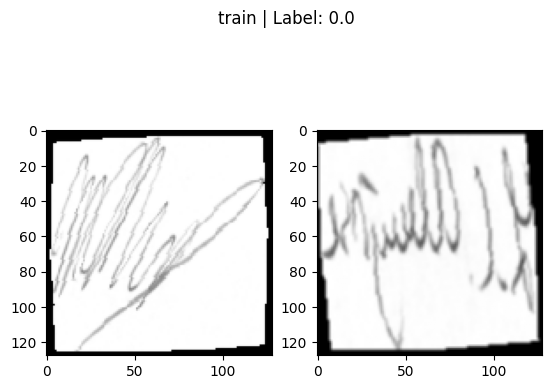

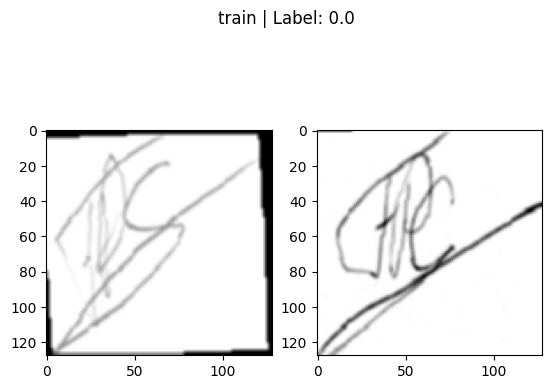

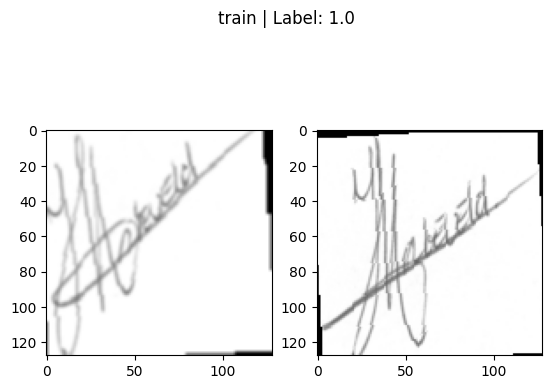


===== VAL SANITY CHECK =====
img1 shape: torch.Size([8, 1, 128, 128])
img2 shape: torch.Size([8, 1, 128, 128])
labels shape: torch.Size([8])
dtype: torch.float32
unique labels: tensor([0., 1.])
val sanity passed.


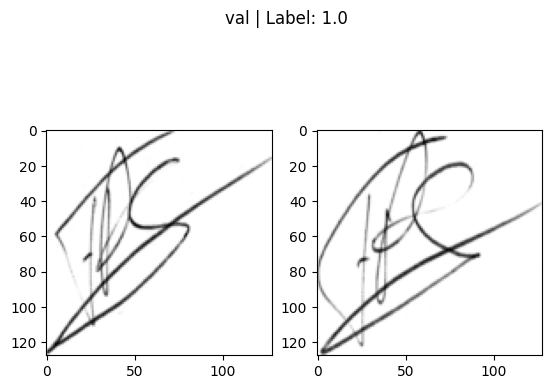

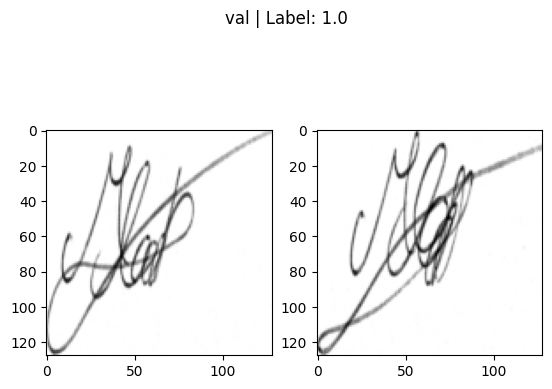

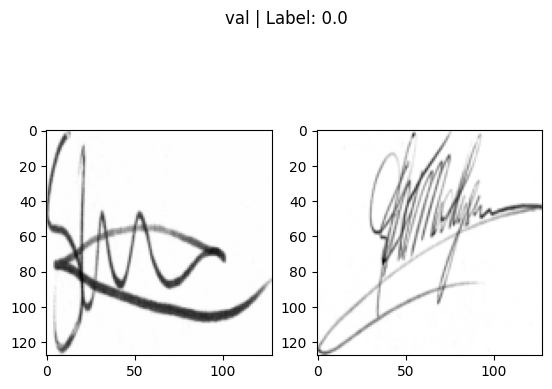


===== TEST SANITY CHECK =====
img1 shape: torch.Size([8, 1, 128, 128])
img2 shape: torch.Size([8, 1, 128, 128])
labels shape: torch.Size([8])
dtype: torch.float32
unique labels: tensor([0., 1.])
test sanity passed.


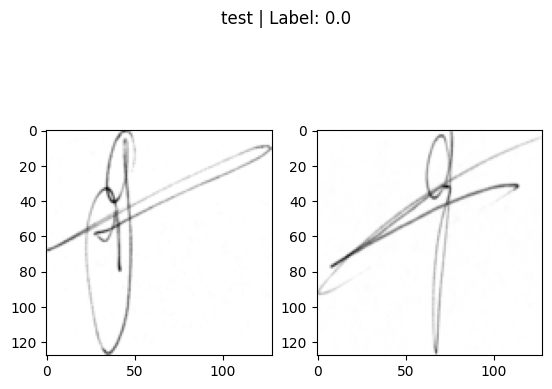

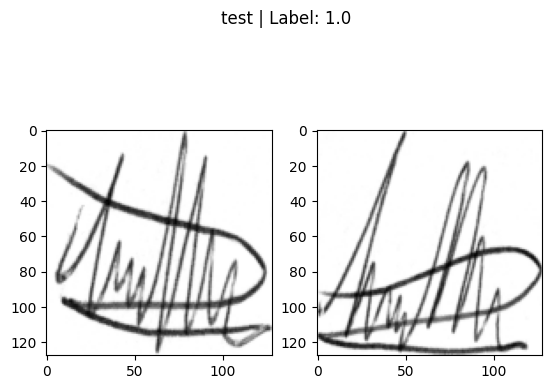

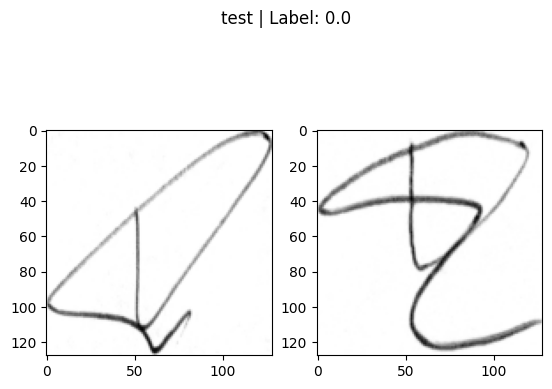


All splits passed sanity check.


In [6]:
run_full_sanity_check()